# 🏥 Disease Classification Using Healthcare Data
### Data Analytics Project — Python

**Dataset:** Disease Prediction Using Machine Learning (Kaggle)  
**Link:** https://www.kaggle.com/datasets/kaushil268/disease-prediction-using-machine-learning

---
**Project Pipeline:**
1. Data Loading & Exploration
2. Exploratory Data Analysis (EDA)
3. Data Preprocessing
4. Model Building (Decision Tree, Random Forest, Naive Bayes, KNN)
5. Model Evaluation & Comparison
6. Feature Importance
7. Disease Prediction Function

## 📦 Step 1: Import Libraries

In [17]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn - Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# Sklearn - Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Sklearn - Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Plot styling
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 2: Load the Dataset

> **Instructions:** Download `Training.csv` and `Testing.csv` from the Kaggle link above and place them in the same folder as this notebook.

In [18]:
from google.colab import files
import io

uploaded = files.upload()  # A file picker will pop up

train_df = pd.read_csv('Training.csv')
test_df  = pd.read_csv('Testing.csv')

print(f'Training set shape : {train_df.shape}')
print(f'Testing set shape  : {test_df.shape}')

train_df.head()

KeyboardInterrupt: 

## 🔍 Step 3: Exploratory Data Analysis (EDA)

In [ ]:
# ── Basic info ──
print('=== Dataset Info ===')
print(f'Total Rows    : {train_df.shape[0]}')
print(f'Total Columns : {train_df.shape[1]}')
print(f'\nTarget Column : prognosis')
print(f'Unique Diseases: {train_df["prognosis"].nunique()}')
print(f'\nMissing Values :\n{train_df.isnull().sum().sum()} (total)')

In [ ]:
# ── Disease Distribution ──
disease_counts = train_df['prognosis'].value_counts()

plt.figure(figsize=(16, 8))
bars = plt.barh(disease_counts.index, disease_counts.values,
                color=sns.color_palette('Set2', len(disease_counts)))
plt.xlabel('Number of Records', fontsize=13)
plt.title('📊 Disease Distribution in Training Data', fontsize=16, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for bar, val in zip(bars, disease_counts.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('disease_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✅ {len(disease_counts)} unique diseases found')

In [ ]:
# ── Top 15 Most Common Symptoms ──
symptom_cols = [col for col in train_df.columns if col != 'prognosis']
symptom_freq = train_df[symptom_cols].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=symptom_freq.values, y=symptom_freq.index, palette='Blues_r')
plt.xlabel('Frequency (across all patients)', fontsize=13)
plt.title('🩺 Top 15 Most Frequent Symptoms', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('top_symptoms.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Symptom Co-occurrence Heatmap (Top 20 symptoms) ──
top20_symptoms = symptom_freq.head(20).index.tolist()
corr_matrix = train_df[top20_symptoms].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False,
            cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Correlation'})
plt.title('🔥 Symptom Co-occurrence Heatmap (Top 20 Symptoms)',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('symptom_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 🧹 Step 4: Data Preprocessing

In [ ]:
# ── Encode target labels ──
le = LabelEncoder()

# Drop unnamed last column if present (some Kaggle versions have it)
train_df = train_df.loc[:, ~train_df.columns.str.contains('^Unnamed')]
test_df  = test_df.loc[:,  ~test_df.columns.str.contains('^Unnamed')]

# Features and target
X_train = train_df.drop('prognosis', axis=1)
y_train = le.fit_transform(train_df['prognosis'])

X_test  = test_df.drop('prognosis', axis=1)
y_test  = le.transform(test_df['prognosis'])

print(f'Training Features Shape : {X_train.shape}')
print(f'Testing  Features Shape : {X_test.shape}')
print(f'Number of Symptom Features : {X_train.shape[1]}')
print(f'Number of Target Classes   : {len(le.classes_)}')
print(f'\nDisease Labels (first 10): {list(le.classes_[:10])}')

## 🤖 Step 5: Model Building

We train **4 classification models** and compare their performance:
- Decision Tree
- Random Forest
- Naive Bayes
- K-Nearest Neighbors (KNN)

In [16]:
# ── Define models ──
models = {
    'Decision Tree'  : DecisionTreeClassifier(random_state=42),
    'Random Forest'  : RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes'    : GaussianNB(),
    'KNN (k=5)'      : KNeighborsClassifier(n_neighbors=5)
}

results = {}

print('Training models...\n')
for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    acc    = accuracy_score(y_test, y_pred) * 100
    cv_acc = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean() * 100

    results[name] = {
        'model'     : model,
        'y_pred'    : y_pred,
        'accuracy'  : round(acc, 2),
        'cv_accuracy': round(cv_acc, 2)
    }
    print(f'✅ {name:<20} Test Acc: {acc:.2f}%   CV Acc (5-fold): {cv_acc:.2f}%')

Training models...

✅ Decision Tree        Test Acc: 97.62%   CV Acc (5-fold): 100.00%
✅ Random Forest        Test Acc: 97.62%   CV Acc (5-fold): 100.00%
✅ Naive Bayes          Test Acc: 100.00%   CV Acc (5-fold): 100.00%
✅ KNN (k=5)            Test Acc: 100.00%   CV Acc (5-fold): 100.00%


## 📊 Step 6: Model Comparison

In [19]:
# ── Summary Table ──
summary = pd.DataFrame({
    'Model'          : list(results.keys()),
    'Test Accuracy %': [results[m]['accuracy']   for m in results],
    'CV Accuracy %'  : [results[m]['cv_accuracy'] for m in results]
}).sort_values('Test Accuracy %', ascending=False).reset_index(drop=True)

print('='*55)
print('          MODEL PERFORMANCE SUMMARY')
print('='*55)
print(summary.to_string(index=False))
print('='*55)
print(f'\n🏆 Best Model: {summary.iloc[0]["Model"]} ({summary.iloc[0]["Test Accuracy %"]}%)')

          MODEL PERFORMANCE SUMMARY
        Model  Test Accuracy %  CV Accuracy %
    KNN (k=5)           100.00          100.0
  Naive Bayes           100.00          100.0
Random Forest            97.62          100.0
Decision Tree            97.62          100.0

🏆 Best Model: KNN (k=5) (100.0%)


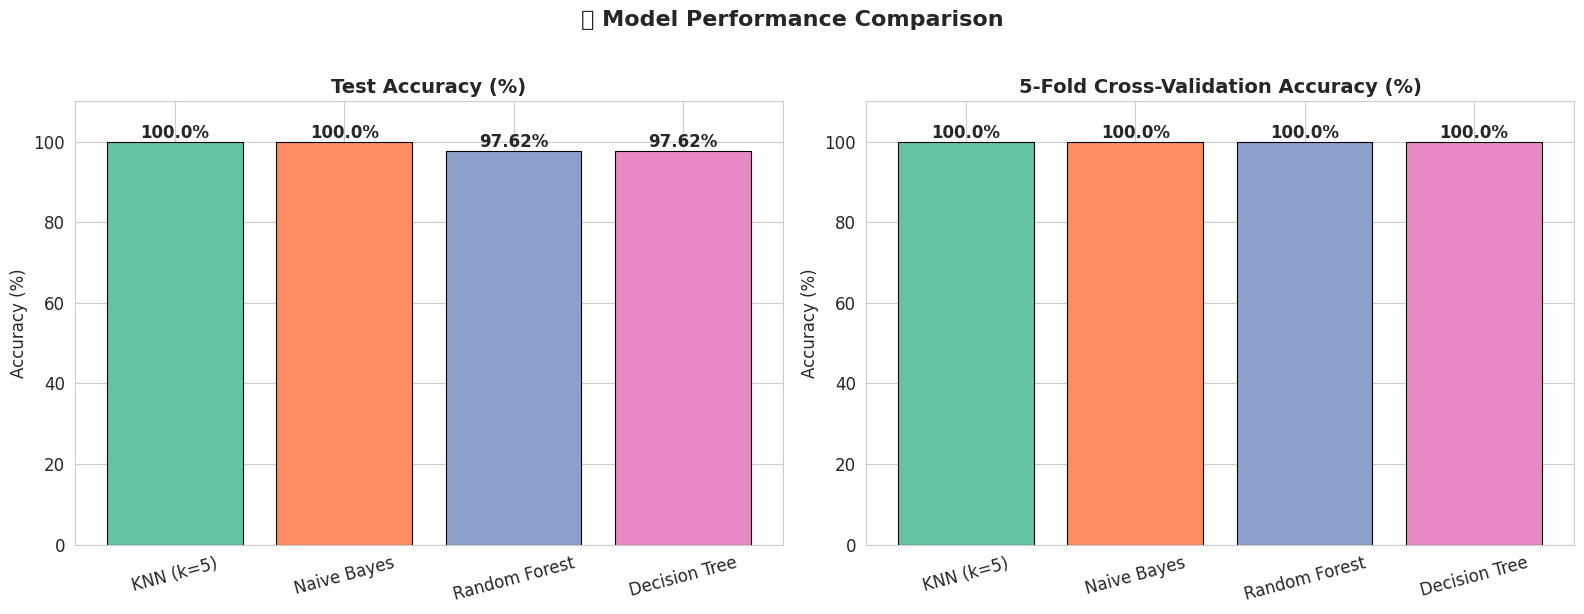

In [20]:
# ── Accuracy Comparison Bar Chart ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = sns.color_palette('Set2', 4)

# Test Accuracy
axes[0].bar(summary['Model'], summary['Test Accuracy %'], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Test Accuracy (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 110)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(summary['Test Accuracy %']):
    axes[0].text(i, v + 1, f'{v}%', ha='center', fontweight='bold', fontsize=12)

# CV Accuracy
axes[1].bar(summary['Model'], summary['CV Accuracy %'], color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('5-Fold Cross-Validation Accuracy (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_ylim(0, 110)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(summary['CV Accuracy %']):
    axes[1].text(i, v + 1, f'{v}%', ha='center', fontweight='bold', fontsize=12)

plt.suptitle('📊 Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 🎯 Step 7: Confusion Matrix — Best Model

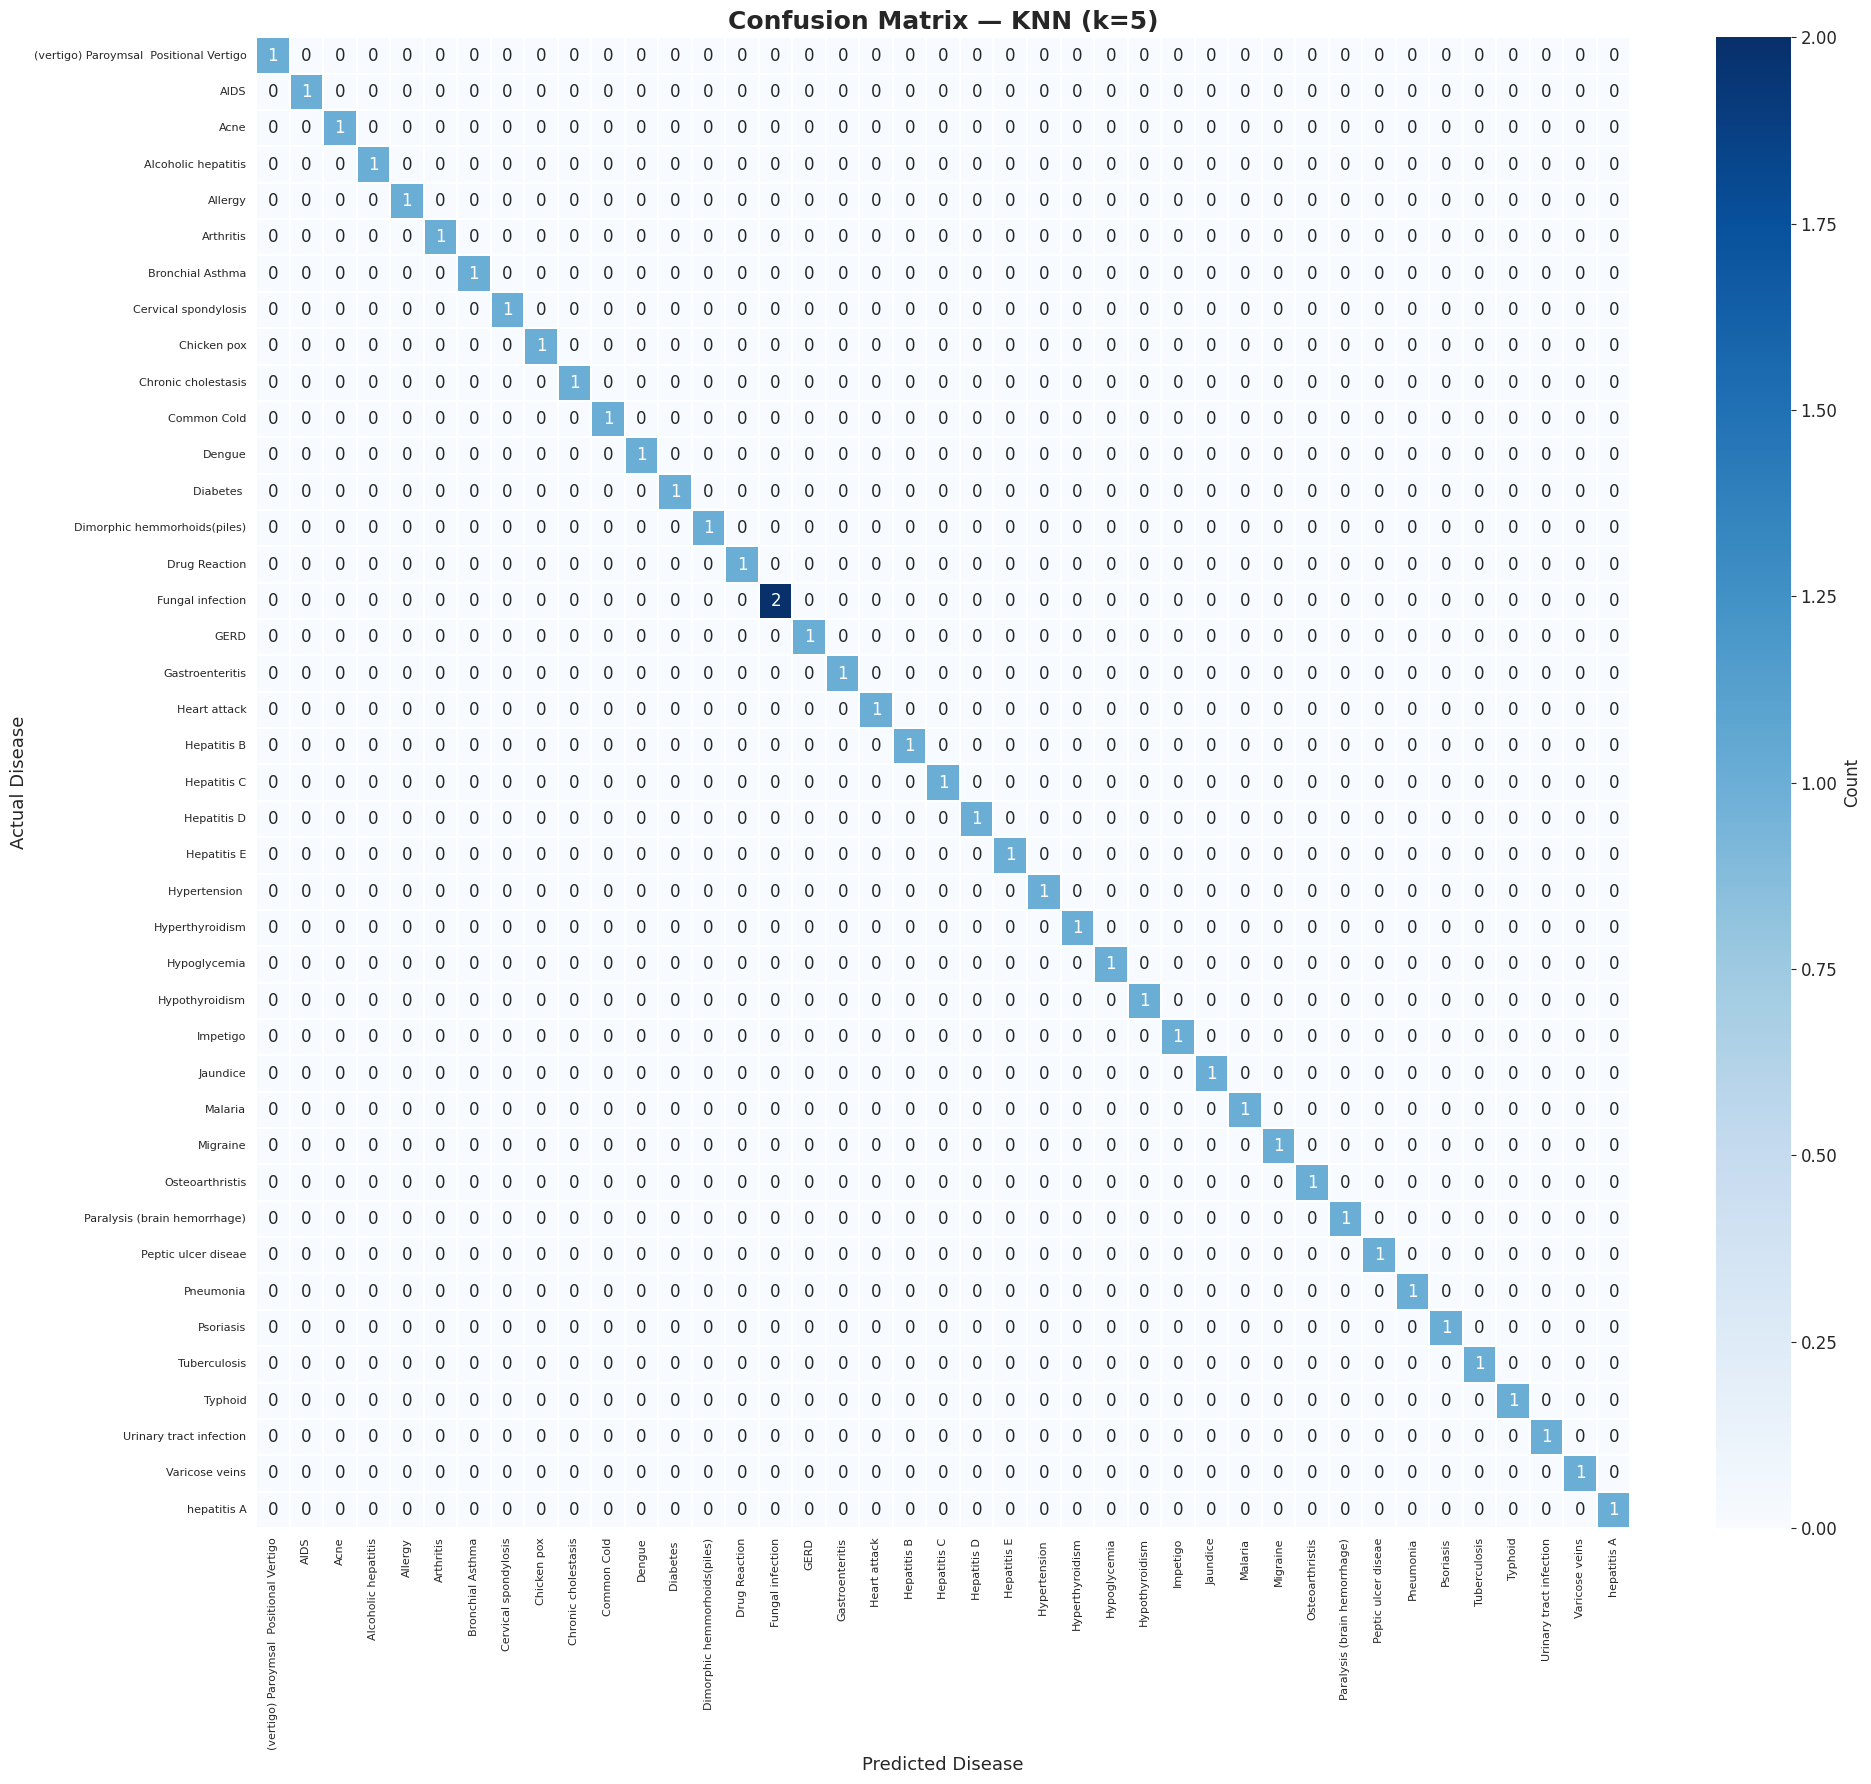

In [21]:
# ── Confusion Matrix for best model ──
best_model_name = summary.iloc[0]['Model']
best_y_pred     = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, best_y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            linewidths=0.3, cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix — {best_model_name}', fontsize=18, fontweight='bold')
plt.xlabel('Predicted Disease', fontsize=13)
plt.ylabel('Actual Disease', fontsize=13)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Detailed Classification Report ──
print(f'\n📋 Classification Report — {best_model_name}\n')
print('='*70)
print(classification_report(y_test, best_y_pred,
                             target_names=le.classes_))


📋 Classification Report — KNN (k=5)

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       1.00      1.00      1.00         1
                    Chronic cholestasis       1.00      1.00      1.00         1
                            Common Cold       1.00      1.00      1.00

## 🌳 Step 8: Feature Importance (Random Forest)

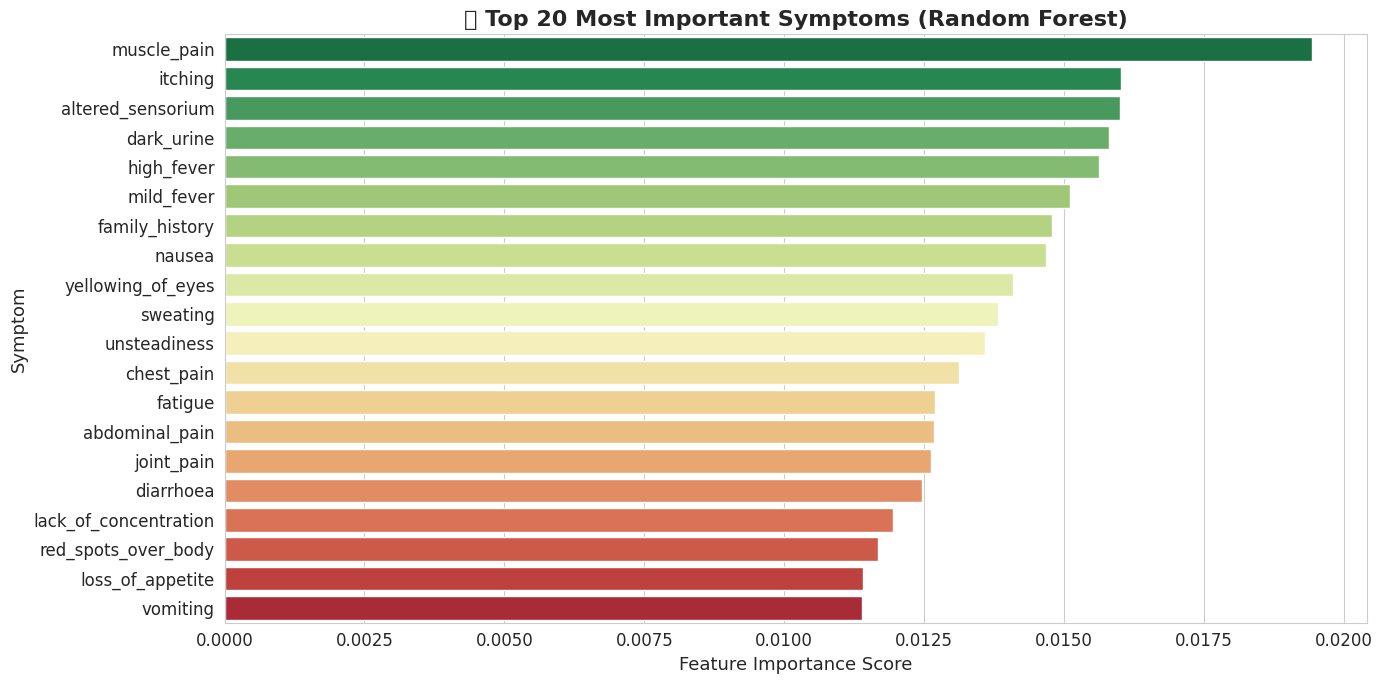


Top 10 Most Predictive Symptoms:
          Symptom  Importance
      muscle_pain    0.019439
          itching    0.016014
altered_sensorium    0.016001
       dark_urine    0.015811
       high_fever    0.015623
       mild_fever    0.015100
   family_history    0.014786
           nausea    0.014670
yellowing_of_eyes    0.014079
         sweating    0.013823


In [23]:
# ── Random Forest Feature Importance ──
rf_model     = results['Random Forest']['model']
importances  = rf_model.feature_importances_
feat_names   = X_train.columns

feat_df = pd.DataFrame({'Symptom': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(20)

plt.figure(figsize=(14, 7))
sns.barplot(x='Importance', y='Symptom', data=feat_df,
            palette='RdYlGn_r')
plt.title('🌳 Top 20 Most Important Symptoms (Random Forest)',
          fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance Score', fontsize=13)
plt.ylabel('Symptom', fontsize=13)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Most Predictive Symptoms:')
print(feat_df.head(10).to_string(index=False))

## 🔮 Step 9: Disease Prediction Function

Enter your symptoms and predict the disease!

In [28]:
# ── Prediction Function ──
def predict_disease(symptoms_list, model_name='Random Forest'):
    """
    Predict disease based on a list of symptoms.

    Parameters:
        symptoms_list (list): List of symptom strings (must match column names)
        model_name (str)    : One of 'Random Forest', 'Decision Tree',
                              'Naive Bayes', 'KNN (k=5)'
    Returns:
        str: Predicted disease name
    """
    # Build input vector
    input_vector = np.zeros(len(X_train.columns))
    col_list     = list(X_train.columns)

    unrecognized = []
    for symptom in symptoms_list:
        symptom = symptom.strip().lower().replace(' ', '_')
        if symptom in col_list:
            input_vector[col_list.index(symptom)] = 1
        else:
            unrecognized.append(symptom)

    if unrecognized:
        print(f'⚠️  Unrecognized symptoms (ignored): {unrecognized}')

    # Predict
    model         = results[model_name]['model']
    pred_encoded  = model.predict([input_vector])[0]
    disease       = le.inverse_transform([pred_encoded])[0]

    # Probability (if supported)
    if hasattr(model, 'predict_proba'):
        proba        = model.predict_proba([input_vector])[0]
        confidence   = round(max(proba) * 100, 2)
    else:
        confidence = 'N/A'

    print(f'\n🔍 Symptoms Entered  : {symptoms_list}')
    print(f'🏥 Predicted Disease : {disease}')
    print(f'📈 Confidence        : {confidence}%')
    return disease


# ── Example Prediction 1: Malaria-like symptoms ──
print('='*55)
print('         EXAMPLE PREDICTION 1')
print('='*55)
predict_disease(['chills', 'vomiting', 'high_fever',
                 'sweating', 'headache', 'nausea'])

print()

# ── Example Prediction 2: Diabetes-like symptoms ──
print('='*55)
print('         EXAMPLE PREDICTION 2')
print('='*55)
predict_disease(['fatigue', 'weight_loss', 'restlessness',
                 'lethargy', 'irregular_sugar_level', 'blurred_and_distorted_vision'])

# Example 3 (TEST YOUR OWN)
print()
print('='*55)
print('         TEST YOUR OWN')
print('='*55)
predict_disease(['itching',
   'skin_rash',
   'nodal_skin_eruptions',
   'continuous_sneezing',
   'shivering',
   'chills',
   'joint_pain',
   'stomach_pain',
   'acidity',
   'ulcers_on_tongue',
  'muscle_wasting','vomiting'])

         EXAMPLE PREDICTION 1

🔍 Symptoms Entered  : ['chills', 'vomiting', 'high_fever', 'sweating', 'headache', 'nausea']
🏥 Predicted Disease : Malaria
📈 Confidence        : 40.0%

         EXAMPLE PREDICTION 2

🔍 Symptoms Entered  : ['fatigue', 'weight_loss', 'restlessness', 'lethargy', 'irregular_sugar_level', 'blurred_and_distorted_vision']
🏥 Predicted Disease : Diabetes 
📈 Confidence        : 42.0%

         TEST YOUR OWN

🔍 Symptoms Entered  : ['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing', 'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity', 'ulcers_on_tongue', 'muscle_wasting', 'vomiting']
🏥 Predicted Disease : GERD
📈 Confidence        : 36.0%


'GERD'

In [25]:
# ── Try Your Own Symptoms Here ──
# Uncomment the line below and replace with your symptoms!

# predict_disease(['your_symptom_1', 'your_symptom_2', 'your_symptom_3'])

# All available symptom column names:
print('📋 All available symptoms you can use:')
print('='*60)
for i, col in enumerate(X_train.columns, 1):
    print(f'{i:>3}. {col}')

📋 All available symptoms you can use:
  1. itching
  2. skin_rash
  3. nodal_skin_eruptions
  4. continuous_sneezing
  5. shivering
  6. chills
  7. joint_pain
  8. stomach_pain
  9. acidity
 10. ulcers_on_tongue
 11. muscle_wasting
 12. vomiting
 13. burning_micturition
 14. spotting_ urination
 15. fatigue
 16. weight_gain
 17. anxiety
 18. cold_hands_and_feets
 19. mood_swings
 20. weight_loss
 21. restlessness
 22. lethargy
 23. patches_in_throat
 24. irregular_sugar_level
 25. cough
 26. high_fever
 27. sunken_eyes
 28. breathlessness
 29. sweating
 30. dehydration
 31. indigestion
 32. headache
 33. yellowish_skin
 34. dark_urine
 35. nausea
 36. loss_of_appetite
 37. pain_behind_the_eyes
 38. back_pain
 39. constipation
 40. abdominal_pain
 41. diarrhoea
 42. mild_fever
 43. yellow_urine
 44. yellowing_of_eyes
 45. acute_liver_failure
 46. fluid_overload
 47. swelling_of_stomach
 48. swelled_lymph_nodes
 49. malaise
 50. blurred_and_distorted_vision
 51. phlegm
 52. throat_irrit

## 📌 Step 10: Final Summary

In [29]:
# ── Final Project Summary ──
print('='*60)
print('        DISEASE CLASSIFICATION PROJECT — SUMMARY')
print('='*60)
print(f'  Dataset        : Disease Prediction (Kaggle)')
print(f'  Training Rows  : {train_df.shape[0]}')
print(f'  Testing Rows   : {test_df.shape[0]}')
print(f'  No. of Symptoms: {X_train.shape[1]}')
print(f'  No. of Diseases: {len(le.classes_)}')
print()
print('  Model Results:')
print('  ' + '-'*46)
for _, row in summary.iterrows():
    trophy = '🏆' if _ == 0 else '  '
    print(f'  {trophy} {row["Model"]:<22} → {row["Test Accuracy %"]:>6}%')
print('  ' + '-'*46)
print(f'\n  ✅ Best Model : {summary.iloc[0]["Model"]}')
print(f'  ✅ Accuracy   : {summary.iloc[0]["Test Accuracy %"]}%')
print()
print('  Plots Saved:')
for f in ['disease_distribution.png','top_symptoms.png',
          'symptom_heatmap.png','model_comparison.png',
          'confusion_matrix.png','feature_importance.png']:
    print(f'    • {f}')
print('='*60)

        DISEASE CLASSIFICATION PROJECT — SUMMARY
  Dataset        : Disease Prediction (Kaggle)
  Training Rows  : 4920
  Testing Rows   : 42
  No. of Symptoms: 132
  No. of Diseases: 41

  Model Results:
  ----------------------------------------------
  🏆 KNN (k=5)              →  100.0%
     Naive Bayes            →  100.0%
     Random Forest          →  97.62%
     Decision Tree          →  97.62%
  ----------------------------------------------

  ✅ Best Model : KNN (k=5)
  ✅ Accuracy   : 100.0%

  Plots Saved:
    • disease_distribution.png
    • top_symptoms.png
    • symptom_heatmap.png
    • model_comparison.png
    • confusion_matrix.png
    • feature_importance.png
